In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX rendering (requires LaTeX installed)
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 10              # Set all text to 12 pt
})

from itertools import combinations, permutations

def factorial(N):
    return np.prod(np.arange(1,N+1, 1))

def euclid_distance(p1: np.ndarray, p2: np.ndarray) -> float:
    """
    takes two points p1, p2 as two ndarrays of length d (d: dimension) 
    and calculates the euclidean distance between the two points
    returns distance as float value
    """
    return np.sqrt(np.sum(np.square(p1 - p2)))

def tsp_length(nodes_array: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    
    :param nodes_array: (sorted) array of coordinates of the N nodes
    :type nodes_array: np.ndarray (N, d)
    :return: total traveling distance
    :rtype: float
    """
    # calculate the pairwise differences between two consecutive nodes, keep in mind to return to start
    differences = nodes_array - np.roll(nodes_array, shift=-1, axis=0)
    # calculate individual distances and sum up
    distances = np.sqrt(np.sum(np.square(differences), axis=1))
    return np.sum(distances)

def polar_to_cartesian(r: float, theta: float) -> np.ndarray:
    """
    convert polar coordinates to cartesian coordinates
    
    :param r: radius
    :type r: float
    :param theta: angle in radians
    :type theta: float
    :return: cartesian coordinates as ndarray [x, y]
    :rtype: np.ndarray
    """
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y])

def cartesian_to_polar(x: float, y: float) -> np.ndarray:
    """
    convert cartesian coordinates to polar coordinates
    
    :param x: x coordinate
    :type x: float
    :param y: y coordinate
    :type y: float
    :return: polar coordinates as ndarray [r, theta]
    :rtype: np.ndarray
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return np.column_stack([r, theta])

def tsp_length_from_dist_matrix(distance_matrix: np.ndarray, permutation: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    given the distance matrix D and the current permutation
    
    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)
    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)
    :return: total traveling distance
    :rtype: float
    """
    # sum distances between consecutive nodes (equation 3 in Cerny 1985)
    d = np.sum(distance_matrix[permutation[:-1], permutation[1:]])
    # add distance from last node back to first
    d += distance_matrix[permutation[-1], permutation[0]]
    return d

def metric_time_dep(
    node_coordinates: np.ndarray,
    distance_matrix: np.ndarray,
    permutation: np.ndarray,
    f: float = 0.5,
    M: int = 5,
    traffic_jam_area: np.ndarray = None,
) -> float:
    """
    time dependent metric for the traveling salesman problem
    with traffic jam areas

    :param node_coordinates: array of coordinates of the N nodes
    :type node_coordinates: np.ndarray (N, d)

    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)

    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)

    :return: total traveling distance
    :rtype: float
    """

    if traffic_jam_area is None:
        traffic_jam_area = np.array([[0, 1], [0, 1]])

    def eta(i: int) -> int:
        """determine if node i and node i + 1 are within the traffic jam area"""
        x1, y1 = node_coordinates[permutation[i]]
        x2, y2 = node_coordinates[permutation[(i + 1) % len(permutation)]]

        inside1 = (traffic_jam_area[0, 0] <= x1 <= traffic_jam_area[0, 1]) and \
                  (traffic_jam_area[1, 0] <= y1 <= traffic_jam_area[1, 1])
        inside2 = (traffic_jam_area[0, 0] <= x2 <= traffic_jam_area[0, 1]) and \
                  (traffic_jam_area[1, 0] <= y2 <= traffic_jam_area[1, 1])

        return int(inside1 and inside2)

    def xi(i: int) -> float:
        """calculate the inner Heaviside helper function xi"""
        s = 0.0
        for j in range(i):
            s += distance_matrix[permutation[j],
                                 permutation[(j + 1) % len(permutation)]]
        return s - M

    def correction_term(i: int) -> float:
        """calculate traffic jam correction term"""
        denom = distance_matrix[permutation[i],
                                permutation[(i + 1) % len(permutation)]]
        if denom == 0:
            return 0.0  # avoid division by zero

        return (
            np.heaviside(xi(i), 1)
            * (1 - np.heaviside(xi(i - 1), 1))
            * xi(i)
            / denom
        )

    # calculate the metric
    distance = 0.0
    n = len(permutation)

    for i in range(n):
        base = distance_matrix[permutation[i],
                               permutation[(i + 1) % n]]

        distance += base * (
            1
            + eta(i)
            * (f - 1)
            * (np.heaviside(xi(i - 1), 1) + correction_term(i))
        )

    return float(distance)

def metric_time_dep_vectorized(
    node_coordinates: np.ndarray,
    distance_matrix: np.ndarray,
    permutation: np.ndarray,
    f: float = 0.5,
    M: float = 5.0,
    traffic_jam_area: np.ndarray = np.array([[0, 1], [0, 1]]),
) -> float:
    """
    time dependent metric for the traveling salesman problem
    with traffic jam areas

    :param node_coordinates: array of coordinates of the N nodes
    :type node_coordinates: np.ndarray (N, d)

    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)

    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type permutation: np.ndarray (N)

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)

    :return: total traveling distance
    :rtype: float
    """
        
    n = len(permutation)

    # --- 1. tour edges (i -> i+1) ---
    i_idx = permutation
    j_idx = permutation[np.roll(np.arange(n), +1)]

    edge_distances = distance_matrix[i_idx, j_idx]   # shape (n,)

    # --- 2. eta(i): both nodes in jam area ---
    coords_i = node_coordinates[i_idx]
    coords_j = node_coordinates[j_idx]

    in_area_i = (
        (traffic_jam_area[0, 0] <= coords_i[:, 0]) &
        (coords_i[:, 0] <= traffic_jam_area[0, 1]) &
        (traffic_jam_area[1, 0] <= coords_i[:, 1]) &
        (coords_i[:, 1] <= traffic_jam_area[1, 1])
    )

    in_area_j = (
        (traffic_jam_area[0, 0] <= coords_j[:, 0]) &
        (coords_j[:, 0] <= traffic_jam_area[0, 1]) &
        (traffic_jam_area[1, 0] <= coords_j[:, 1]) &
        (coords_j[:, 1] <= traffic_jam_area[1, 1])
    )

    eta = in_area_i & in_area_j
    eta = eta.astype(float)

    # --- 3. cumulative distance Xi(i) ---
    # Xi(i) = total distance traveled before edge i minus M
    cumulative_dist = np.cumsum(edge_distances)
    xi = cumulative_dist - M

    # shift version for xi(i-1)
    xi_prev = np.roll(xi, 1)

    # --- 4. Heaviside ---
    H_xi = np.heaviside(xi, 1)
    H_prev = np.heaviside(xi_prev, 1)

    # --- 5. Correction term ---
    # avoid divide-by-zero
    denom = np.where(edge_distances == 0, 1e-12, edge_distances)

    correction = H_xi * (1 - H_prev) * xi / denom

    # --- 6. Final time-dependent metric ---
    distance = np.sum(
        edge_distances
        * (
            1
            + eta * (f - 1) * (H_prev + correction)
        )
    )

    return float(distance)



In [ ]:
# define N nodes, uniformly spaced around a circle
N = 8
R = 1
phi = np.array([2 * np.pi * i / N + np.pi / 2 for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

# brute force TSP solution
# always start and end at node 0
# get all permutations of the nodes excluding the first one
node_indices = np.arange(N)
perms = permutations(node_indices)
tours = nodes[np.array([[0] + list(p) + [0] for p in perms])]
lengths = np.array([tsp_length(tour) for tour in tours])




NameError: name 'min_length' is not defined

In [ ]:
# best / worst / random indices
min_index = np.argmin(lengths)
max_index = np.argmax(lengths)

# choose a random tour that is not min or max
all_indices = np.arange(len(tours))
valid_indices = np.delete(all_indices, [min_index, max_index])
random_tour_idx = np.random.choice(valid_indices)

# create subplots
fig, ax = plt.subplots(3, 1, figsize=(3.4, 6))

for i, idx in enumerate([max_index, random_tour_idx, min_index]):
    tour = tours[idx]

    # axis settings
    ax[i].set_aspect('equal')
    ax[i].axis('off')
    ax[i].grid(False)

    ax[i].set_ylim(-1.2, 1.2)
    ax[i].set_xlim(-1.2, 1.2)

    # draw circle
    circle = plt.Circle((0, 0), R, color='gray', fill=False)
    ax[i].add_artist(circle)

    # nodes
    ax[i].scatter(nodes[:, 0], nodes[:, 1], color='blue', s=150, zorder=3)

    # highlight start node
    ax[i].scatter(nodes[0, 0], nodes[0, 1],
                  color='yellow', edgecolors='black', s=150, zorder=3)

    # plot path
    ax[i].plot(tour[:, 0], tour[:, 1], 'k-')

    # arrows
    dx = np.diff(tour[:, 0])
    dy = np.diff(tour[:, 1])

    ax[i].quiver(
        tour[:-1, 0], tour[:-1, 1],
        dx, dy,
        angles='xy', scale_units='xy', scale=1,
        color='black', width=0.015, zorder=1
    )

    # optional title
    ax[i].set_title(f"Length = {lengths[idx]:.2f}: ")

plt.tight_layout()
plt.savefig('brute_force_tsp_8_nodes.pdf')
plt.show()


In [ ]:
# plot results
plt.figure()
plt.title(f"TSP solution, length {min_length:4f}")

plt.axis('equal')
plt.axis('off')
plt.grid(False)

circle = plt.Circle((0, 0), R, color='gray', fill=False)
plt.gca().add_artist(circle)
plt.scatter(nodes[:, 0], nodes[:,1])
plt.plot(tours[min_index][:, 0], tours[min_index][:, 1], 'r-')
plt.show()

want_a_lot_of_plots = False
if want_a_lot_of_plots:
    for tour in tours[::]:
        plt.figure()
        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        circle = plt.Circle((0, 0), R, color='gray', fill=False)
        plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1])
        plt.plot(tour[:, 0], tour[:, 1], 'b-', alpha=0.1)
    plt.show()

## Monte-Carlo simulating an approximative TSP result

In [21]:
# implement algorithm
def simulated_annealing(nodes : np.ndarray, temperatures = [0.1, 0.05, 0.01, 0.001], repetitions = 10000, want_plot=True) -> None:
    """
    simulated annealing algorithm for the stationary traveling salesman problem

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d)

    :param temperatures: list of decreasing temperatures for the annealing 
    :type temperatures: list of float

    :param repetitions: number of repetitions per temperature
    :type repetitions: int

    :param want_plots: want a graphical output of the plots
    :type want_plots: boolean
    
    :return: None
    """

    N = len(nodes)

    # calculate the distance matrix D_{i,j} once
    # D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    # nodes shape: (N, 2)
    differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
    D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)

    # randomly generate starting permutation
    starting_perm = np.random.permutation(N)
    # print(starting_perm, min(starting_perm), max(starting_perm))

    length_arr = []

    current_perm = starting_perm.copy()
    current_length = tsp_length_from_dist_matrix(D, current_perm)

    temperature_step = 0  # for loading bar
    for temperature in temperatures:
        for repetition in range(repetitions):
            for i in range(N):
                # sample j from 0 to N-1 with j=!i
                choices = np.arange(N)
                j = np.random.choice(choices[choices != i])

                # generate new permutation
                i_tilde, j_tilde = min(i,j), max(i,j)
                trial_perm = current_perm.copy()
                trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
                trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]
                # calculate corresponding length
                trial_length = tsp_length_from_dist_matrix(D, trial_perm)

                # accept reject step
                if trial_length < current_length:
                    current_perm = trial_perm.copy()
                    current_length = trial_length
                else:
                    x = np.random.rand()
                    if x < np.exp((current_length - trial_length) / temperature):
                        current_perm = trial_perm.copy()
                        current_length = trial_length 
                        
                length_arr.append(current_length)
                
            # loading bar
            fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
            bar_length = 40
            filled_length = int(bar_length * fraction)
            bar = '=' * filled_length + '-' * (bar_length - filled_length)
            print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
        temperature_step += 1
    
    if want_plot:
        # plot the tour
        plt.figure(figsize=(12,12))
        plt.title(f"TSP solution, length {current_length:4f}")

        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        # circle = plt.Circle((0, 0), R, color='gray', fill=False)
        # plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1], color='black')
        tour = np.append(current_perm, current_perm[0])  # close tour
        plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
        plt.savefig('simulated_annealing_final_tour.pdf')
        plt.show()

        print(current_perm)

        # plot the convergence
        plt.figure(figsize=(12,12))
        plt.title(f"TSP convergence")
        plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label=r'2$\pi$')
        for i in range(1, len(temperatures)):
            plt.plot([i * N * repetitions, i * N * repetitions], [0, max(length_arr)], alpha = 0.4, color='grey')
        plt.plot(length_arr, color='black', label='TSP Length')
        # plt.xlim(0.99*len(length_arr), len(length_arr))
        # plt.ylim(6, 13)

        plt.xlabel('Iteration')
        plt.ylabel('TSP Length')
        plt.legend()
        plt.savefig('tsp_sim_annealing_convergence.pdf')
        plt.show()

Annealing progress: |=======================================-| 99.98% Complete (T=0.001)

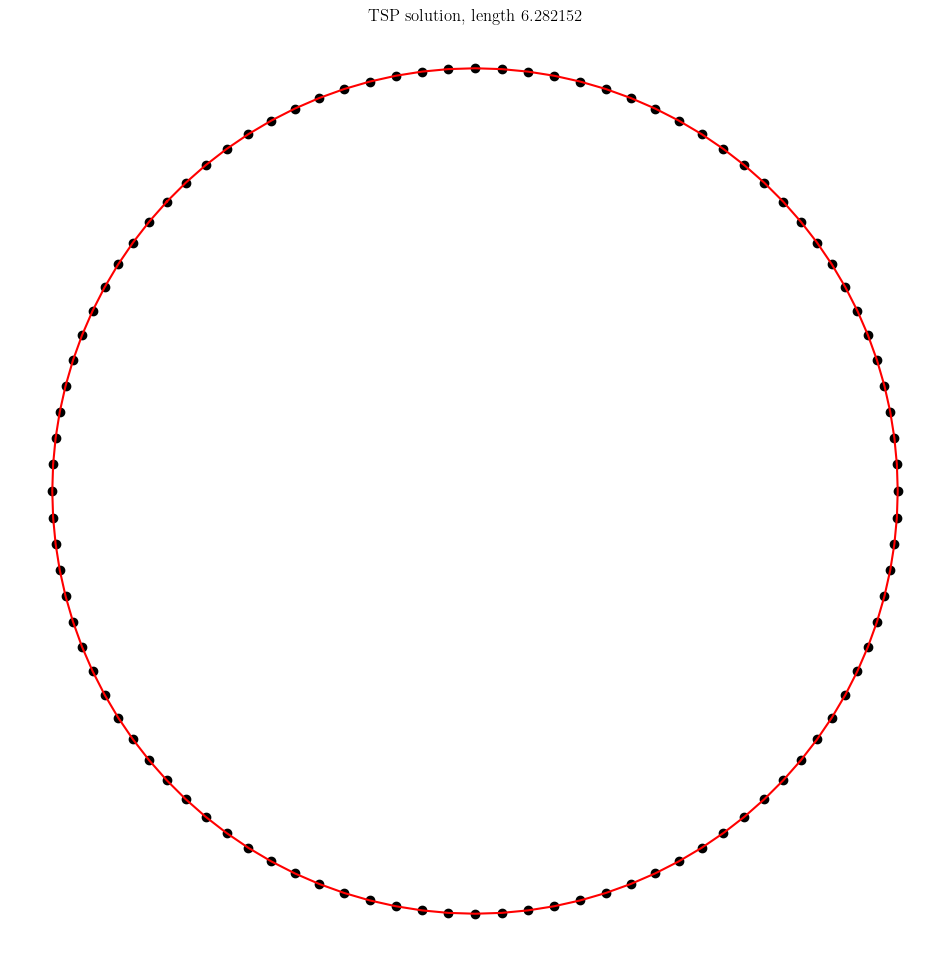

[38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19 18 17 16 15
 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0 99 98 97 96 95 94 93 92 91
 90 89 88 87 86 85 84 83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67
 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43
 42 41 40 39]


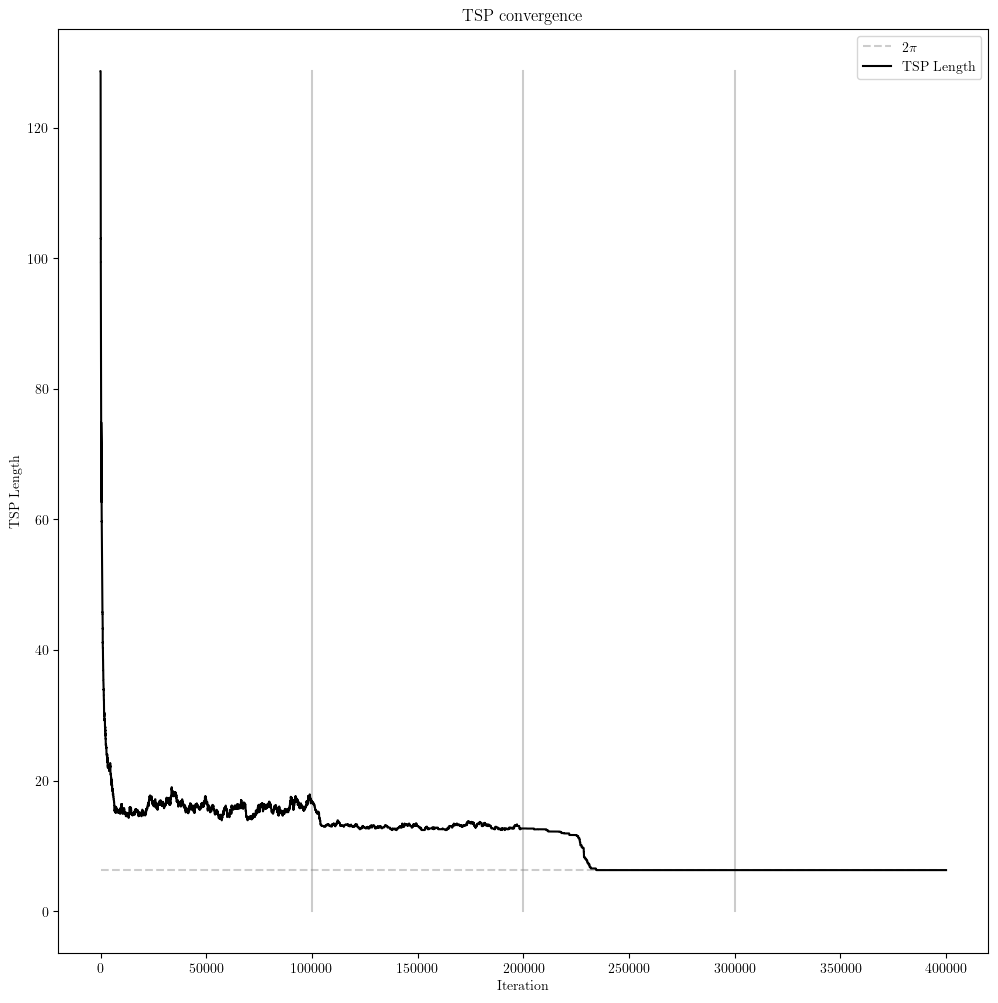

In [22]:
# generating points
# define N nodes, uniformly spaced around a circle
N = 100
R = 1
phi = np.array([2 * np.pi * i / N for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

simulated_annealing(nodes=nodes, repetitions=1000)

Annealing progress: |=======================================-| 99.98% Complete (T=0.001)

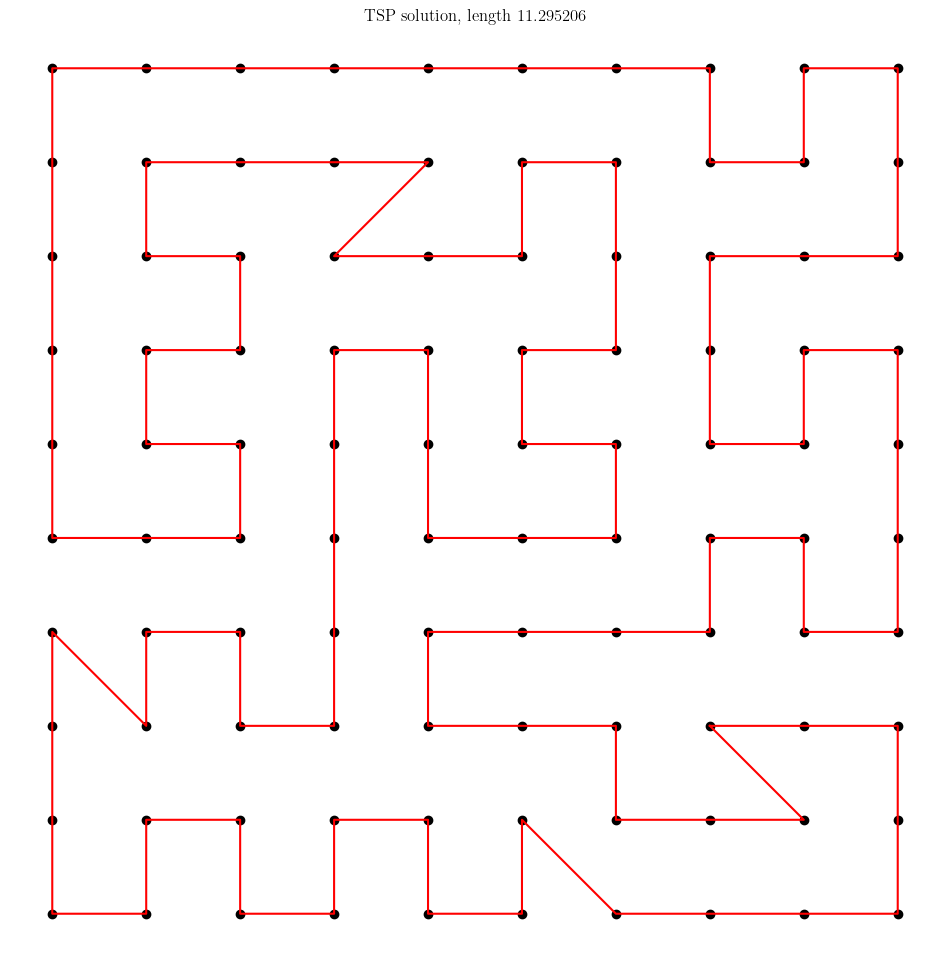

[27 28 29 19  9  8  7  6 15  5  4 14 13  3  2 12 11  1  0 10 20 30 21 31
 32 22 23 33 43 53 63 64 54 44 45 46 56 55 65 66 76 86 85 75 74 73 84 83
 82 81 71 72 62 61 51 52 42 41 40 50 60 70 80 90 91 92 93 94 95 96 97 87
 88 98 99 89 79 78 77 67 57 58 68 69 59 49 39 38 48 47 37 36 35 34 24 25
 26 16 17 18]


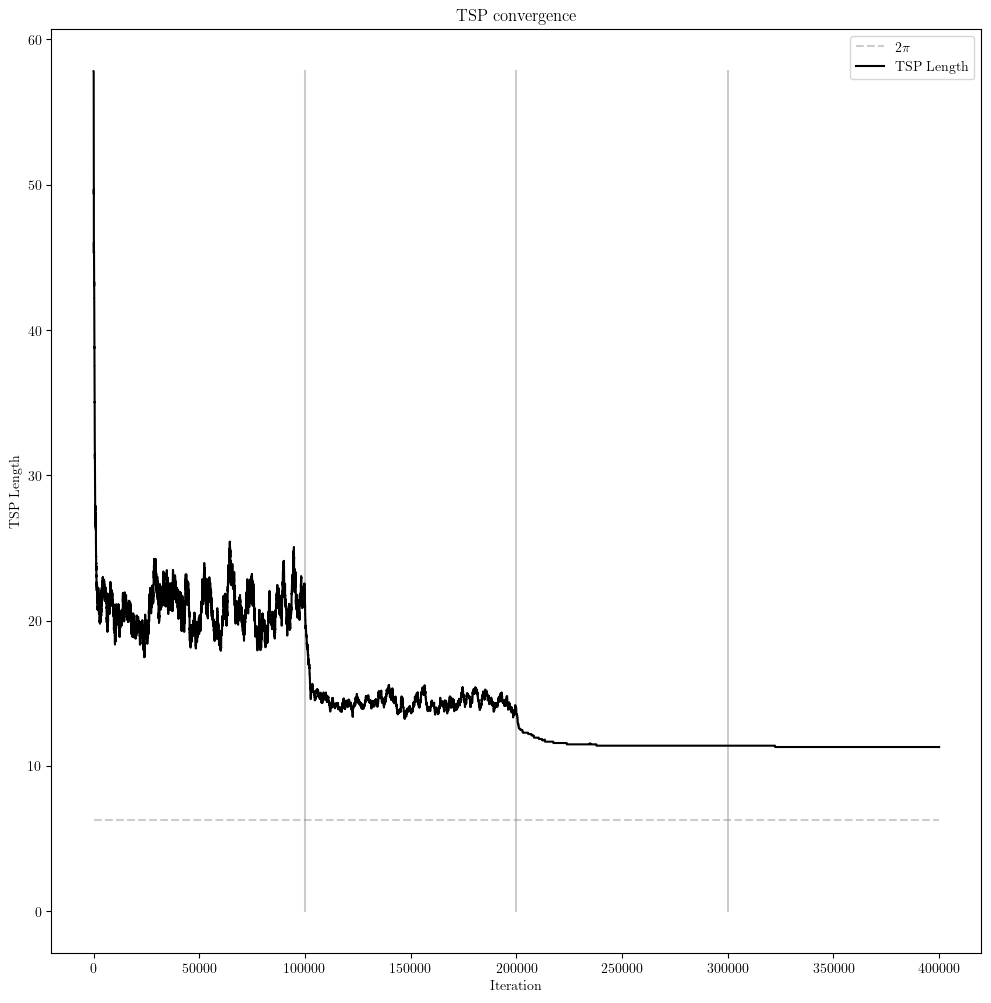

Annealing progress: |=======================================-| 99.98% Complete (T=0.001)

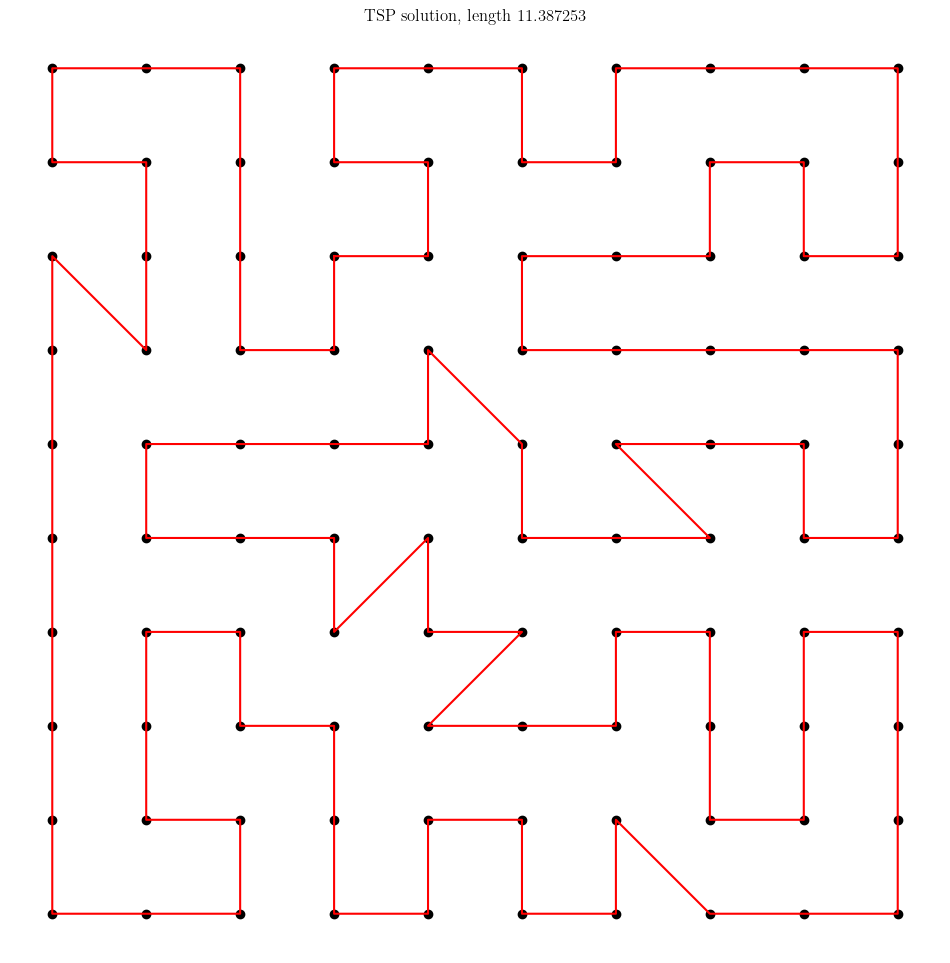

[73 63 62 72 82 92 91 90 80 81 71 61 70 60 50 40 30 20 10  0  1  2 12 11
 21 31 32 22 23 13  3  4 14 15  5  6 16  7  8  9 19 29 39 38 28 18 17 27
 37 36 26 25 24 35 34 44 33 43 42 41 51 52 53 54 64 55 45 46 47 56 57 58
 48 49 59 69 68 67 66 65 75 76 77 87 88 78 79 89 99 98 97 96 86 85 95 94
 93 83 84 74]


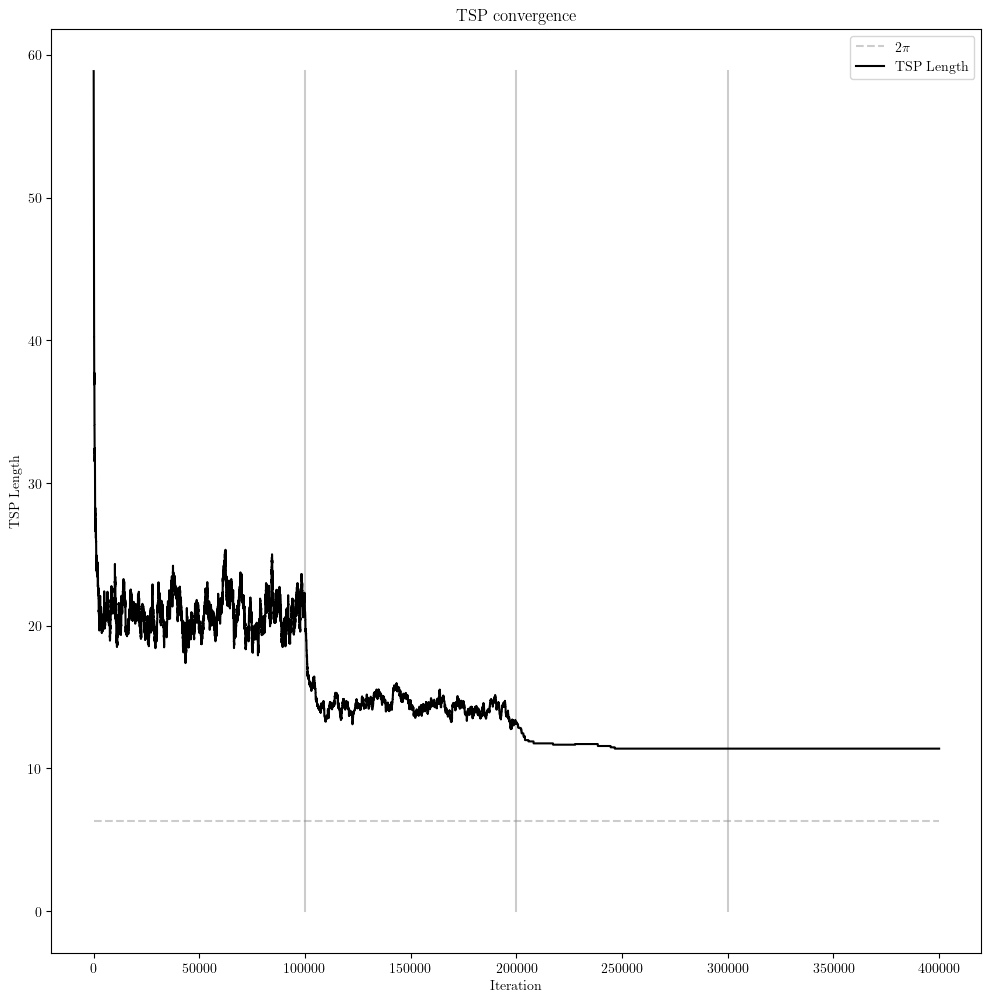

In [23]:
# second example 
# N points aranged on a grid
sqrt_N = 10
N = np.square(sqrt_N)

x = np.linspace(0, 1, sqrt_N)
y = np.linspace(0, 1, sqrt_N)
X, Y = np.meshgrid(x, y)
nodes = np.column_stack([X.flatten(), Y.flatten()])
simulated_annealing(nodes=nodes, repetitions=1000)
simulated_annealing(nodes=nodes, repetitions=1000)


Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

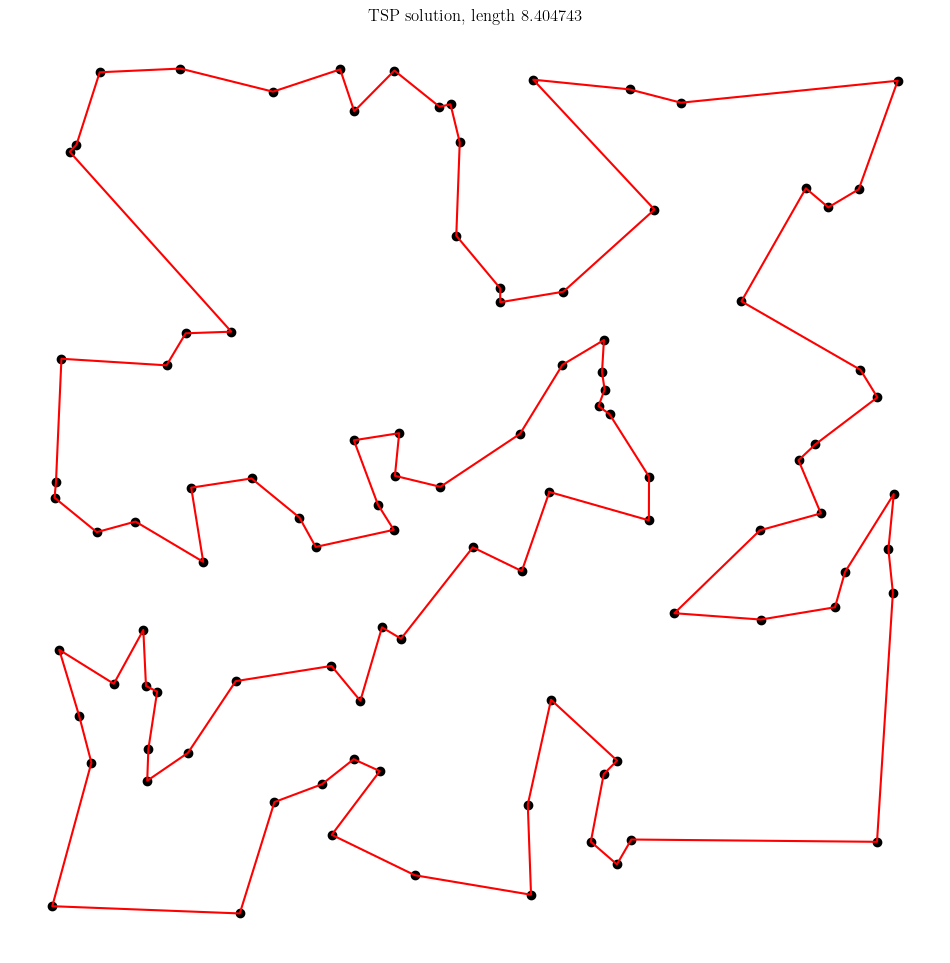

[95 12 64 87 24 85 69  3 71 10 22 39 31 52 16  1 79 40 37 29 88 51  8 74
 81 55 98  6 62 27 80 42 92 97 15 75 84 90 18  4 14  9 54 76 66 59 58 86
 43 72 49  5 34 68 28 11  7 93 47  0 56 19 78 61  2 38 13 65 41 36 63 25
 67 30 53 35 23 82 33 45 44 32 83 57 50 70 89 21 77 17 48 99 20 96 26 73
 60 91 94 46]


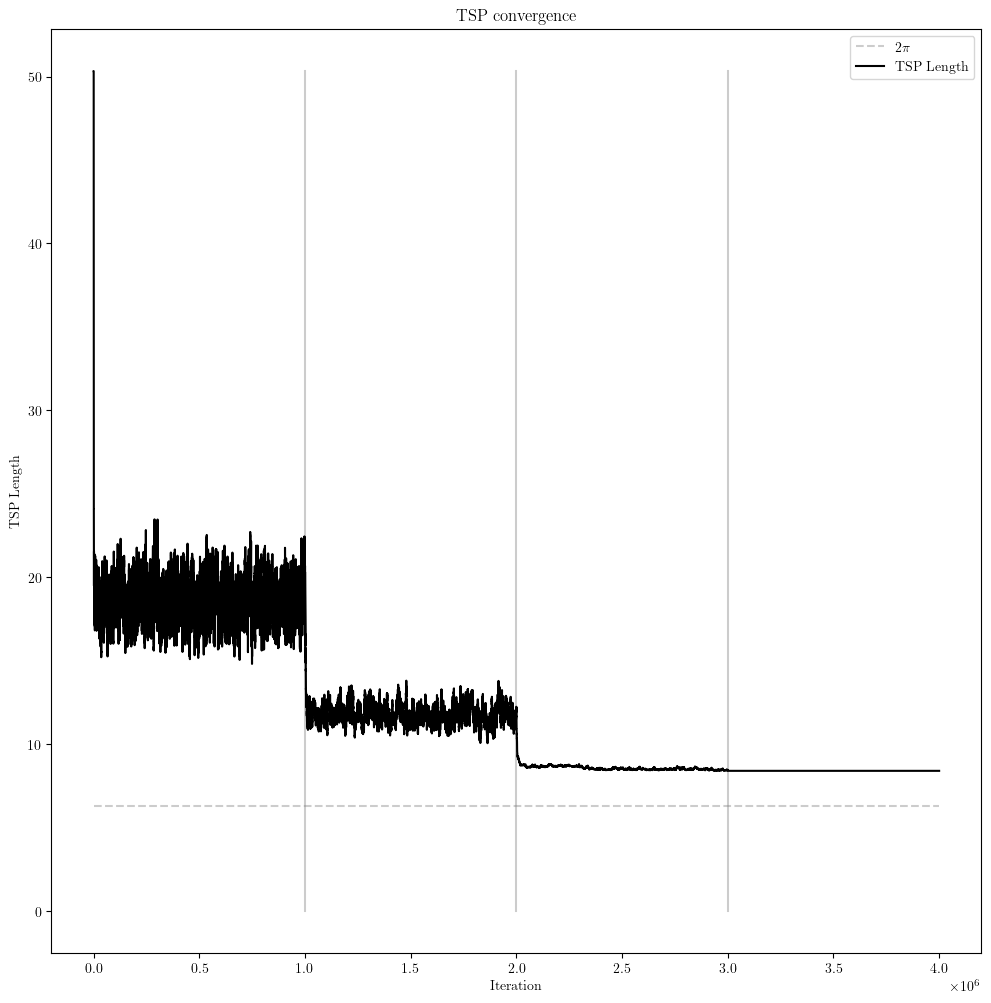

In [32]:
# third example
# N random points in a unit square
N = 100
x = np.random.rand(N)
y = np.random.rand(N)
nodes = np.column_stack([x, y])
simulated_annealing(nodes=nodes)

Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

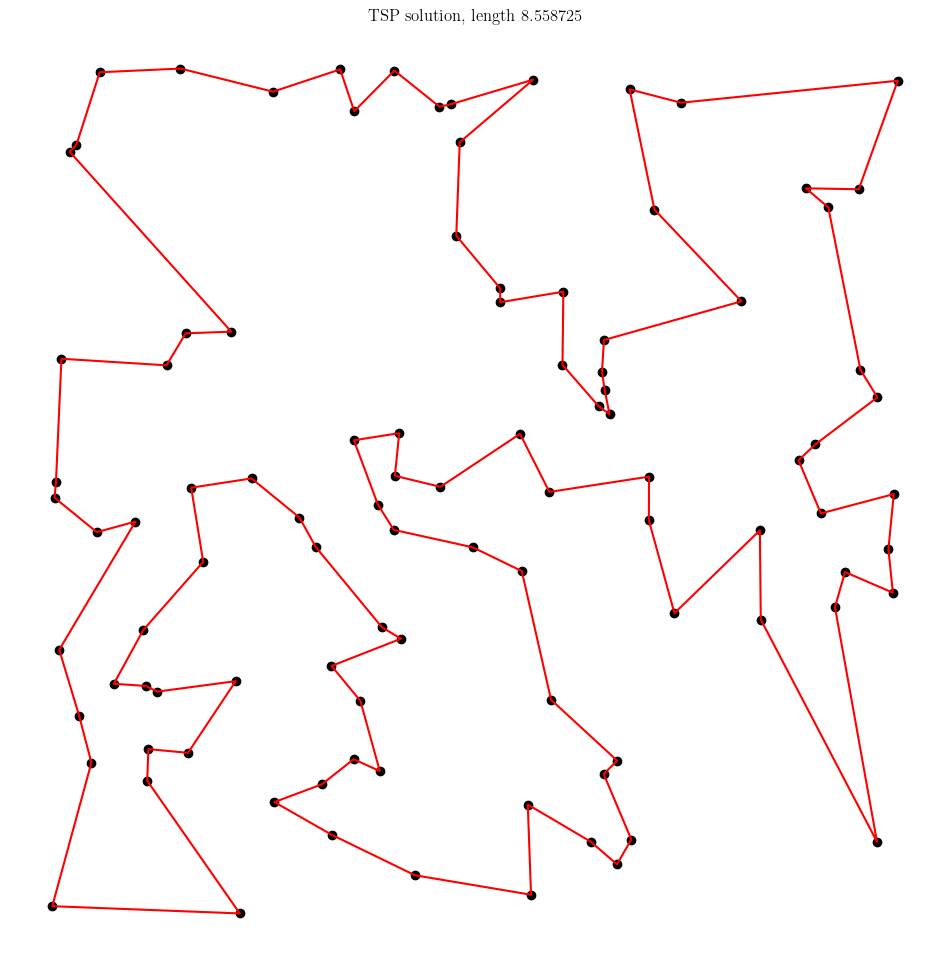

[68 49  5 72 43 86 58 66 34  3 69 85 87 24 71 76 54  9 14  4 59 18 90 84
 75 15 97 92 42 80 27 62  6 98 55 81 74  8 51 70 50 57 83 32 99 48 20 96
 17 77 89 21 88 29 37 40 79 60 91 26 73 82 33 45 44 23 35 53 30 36 41 65
 63 25 67 46 94  1 16 52 31 39 22 10 95 64 12  0 47 56 13 19 78 38  2 61
 93  7 11 28]


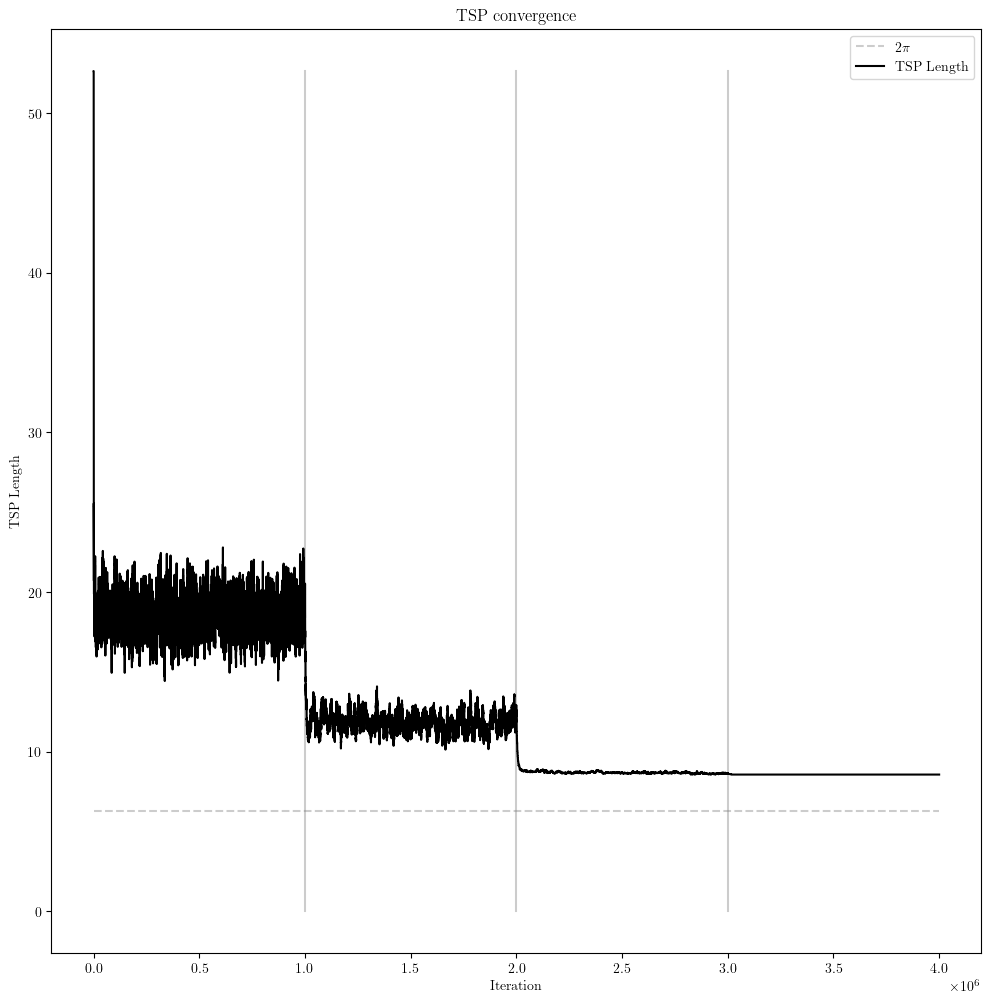

In [33]:
simulated_annealing(nodes=nodes)

To increase convergance we implement second permutation step (Cerny, 1985)


In [36]:
# implement algorithm
def simulated_annealing_improved(nodes : np.ndarray, temperatures = [0.1, 0.05, 0.25, 0.01, 0.005, 0.0025, 0.001, 0.0001], improved_permuation_step_n : int = 7, repetitions = 10000, want_plot=True) -> None:
    """
    simulated annealing algorithm for the stationary traveling salesman problem,
    with improved permutation step at the improved_permuation_step_n's temperature iteration

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d)

    :param temperatures: list of decreasing temperatures for the annealing 
    :type temperatures: list of float

    :param improved_permuation_step_n: step at which the improved permutation step is supposed to be used
    ideally at a temperature close to 0
    :type improved_permuation_step_n: integer

    :param repetitions: number of repetitions per temperature
    :type repetitions: int

    :param want_plots: want a graphical output of the plots
    :type want_plots: boolean
    
    :return: None
    """

    N = len(nodes)

    # calculate the distance matrix D_{i,j} once
    # D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    # nodes shape: (N, 2)
    differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
    D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)

    # randomly generate starting permutation
    starting_perm = np.random.permutation(N)
    # print(starting_perm, min(starting_perm), max(starting_perm))

    length_arr = []

    current_perm = starting_perm.copy()
    current_length = tsp_length_from_dist_matrix(D, current_perm)

    temperature_step = 0
    for temperature in temperatures:
        for repetition in range(repetitions):
            for i in range(N):

                if temperature_step < improved_permuation_step_n:
                    # sample j from 0 to N-1 with j=!i
                    choices = np.arange(N)
                    j = np.random.choice(choices[choices != i])
                else:
                    m = N / 2  # define m to be larger n
                    n = N / 10  # Cerny proposes N / 10 as reasonable value

                    while m > n:
                        # sample j from 0 to N-1
                        choices = np.arange(N)
                        j = np.random.choice(choices)
                        
                        m = min([np.abs(j - i), np.abs(j - i + N), np.abs(j - i - N)])

                # generate new permutation
                i_tilde, j_tilde = min(i,j), max(i,j)
                trial_perm = current_perm.copy()
                trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
                trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]

                # calculate corresponding length
                trial_length = tsp_length_from_dist_matrix(D, trial_perm)

                # accept reject step
                if trial_length < current_length:
                    current_perm = trial_perm.copy()
                    current_length = trial_length
                else:
                    x = np.random.rand()
                    if x < np.exp((current_length - trial_length) / temperature):
                        current_perm = trial_perm.copy()
                        current_length = trial_length 
                        
                length_arr.append(current_length)
                
            # loading bar
            fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
            bar_length = 40
            filled_length = int(bar_length * fraction)
            bar = '=' * filled_length + '-' * (bar_length - filled_length)
            print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
        temperature_step += 1
    
    if want_plot:
        # plot the tour
        plt.figure(figsize=(12,12))
        plt.title(f"TSP solution, length {current_length:4f}")

        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        # circle = plt.Circle((0, 0), R, color='gray', fill=False)
        # plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1], color='black')
        tour = np.append(current_perm, current_perm[0])  # close tour
        plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
        plt.savefig('simulated_annealing_final_tour.pdf')
        plt.show()

        print(current_perm)

        # plot the convergence
        plt.figure(figsize=(12,12))
        plt.title(f"TSP convergence")
        plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label=r'2$\pi$')
        for i in range(1, len(temperatures)):
            plt.plot([i * N * repetitions, i * N * repetitions], [0, max(length_arr)], alpha = 0.4, color='grey')
        plt.plot(length_arr, color='black', label='TSP Length')
        # plt.xlim(0.99*len(length_arr), len(length_arr))
        # plt.ylim(6, 13)

        plt.xlabel('Iteration')
        plt.ylabel('TSP Length')
        plt.legend()
        plt.savefig('tsp_sim_annealing_convergence.pdf')
        plt.show()

Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

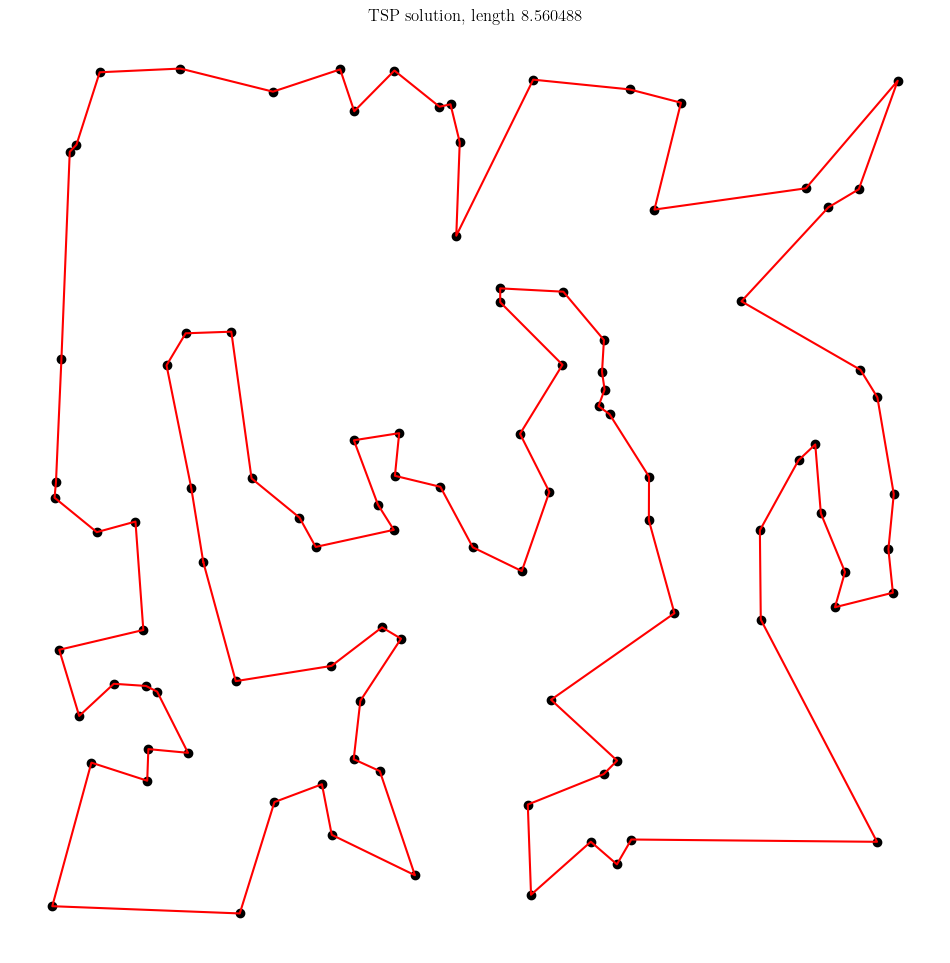

[88 29 98  6 62 37 40 79  1 16 52 31 39 22 94 46 95 10 71 54  9 76  3 69
 85 24 87 64 12  0 67 25 63 30 53 36 41 65 13 56 47  7 11 93 78 19 38  2
 61 28 68 34 49 72 43  5 66 86 58 59 14  4 18 90 84 75 15 97 92 42 80 27
 55 81 74  8 51 21 70 50 89 77 17 20 48 99 57 83 32 44 45 23 35 82 33 73
 91 60 26 96]


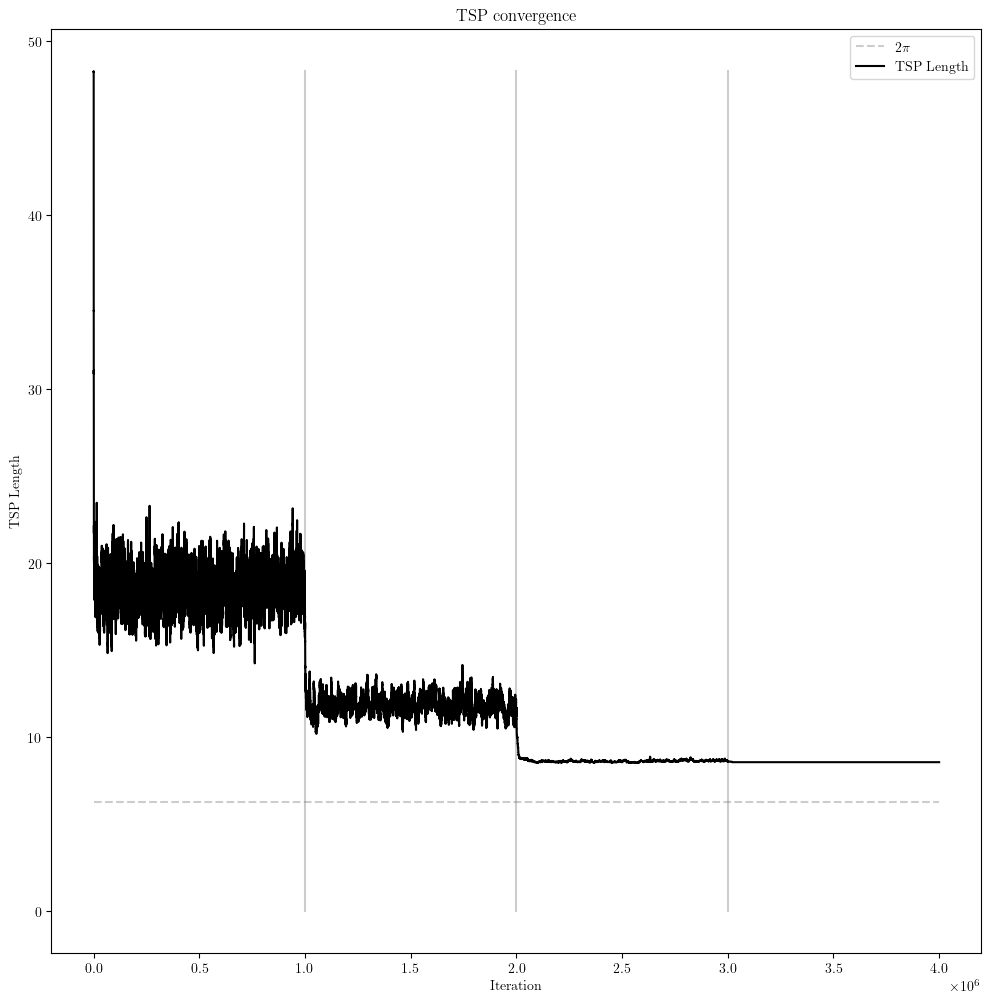

In [34]:

simulated_annealing_improved(nodes=nodes)

Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

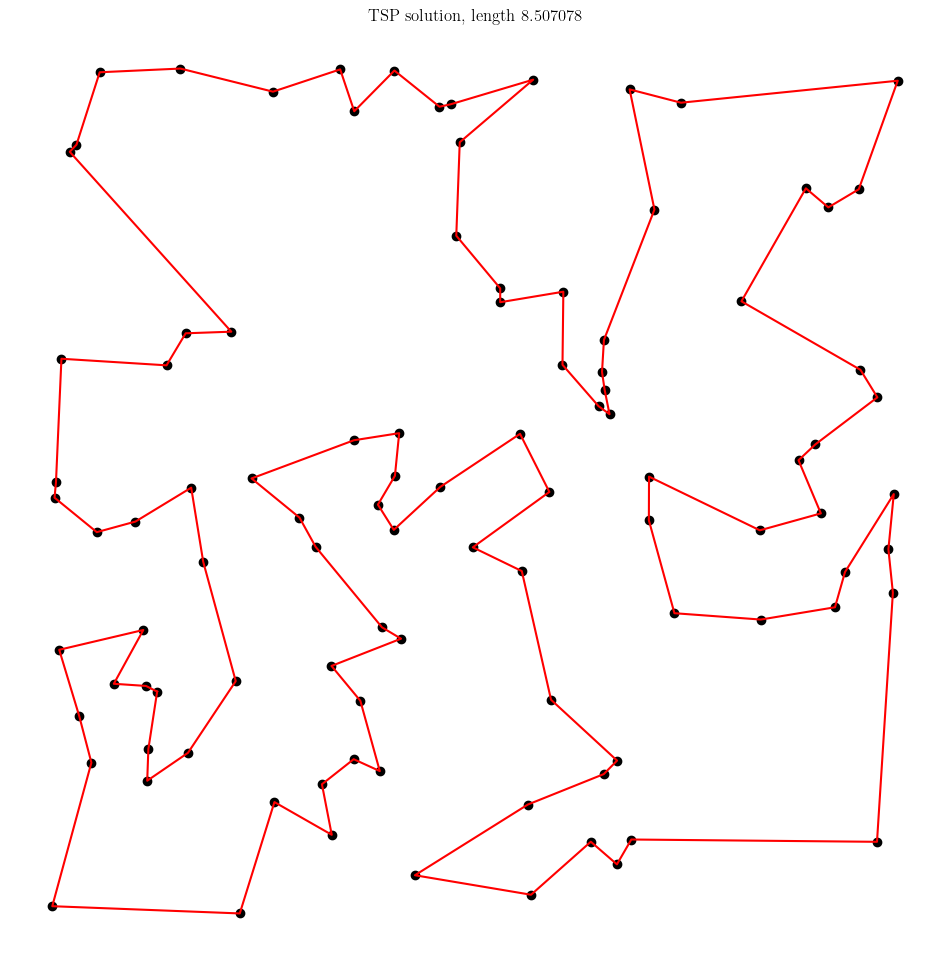

[17 77 89 21 70 50 57 83 32 44 23 45 33 82 73 26 91 60 79 40 37 52 31 39
 16  1 22 10 95 94 46 67 25 63 30 35 53 36 41 65 13 38  2 61 78 19 56  0
 12 64 47 93  7 11 28 68 34  5 49 72 43 86 58 66  3 69 85 87 24 71 76 54
  9 14  4 59 18 90 84 75 15 97 92 42 80 27 62  6 98 55 81 74  8 51 29 88
 96 20 99 48]


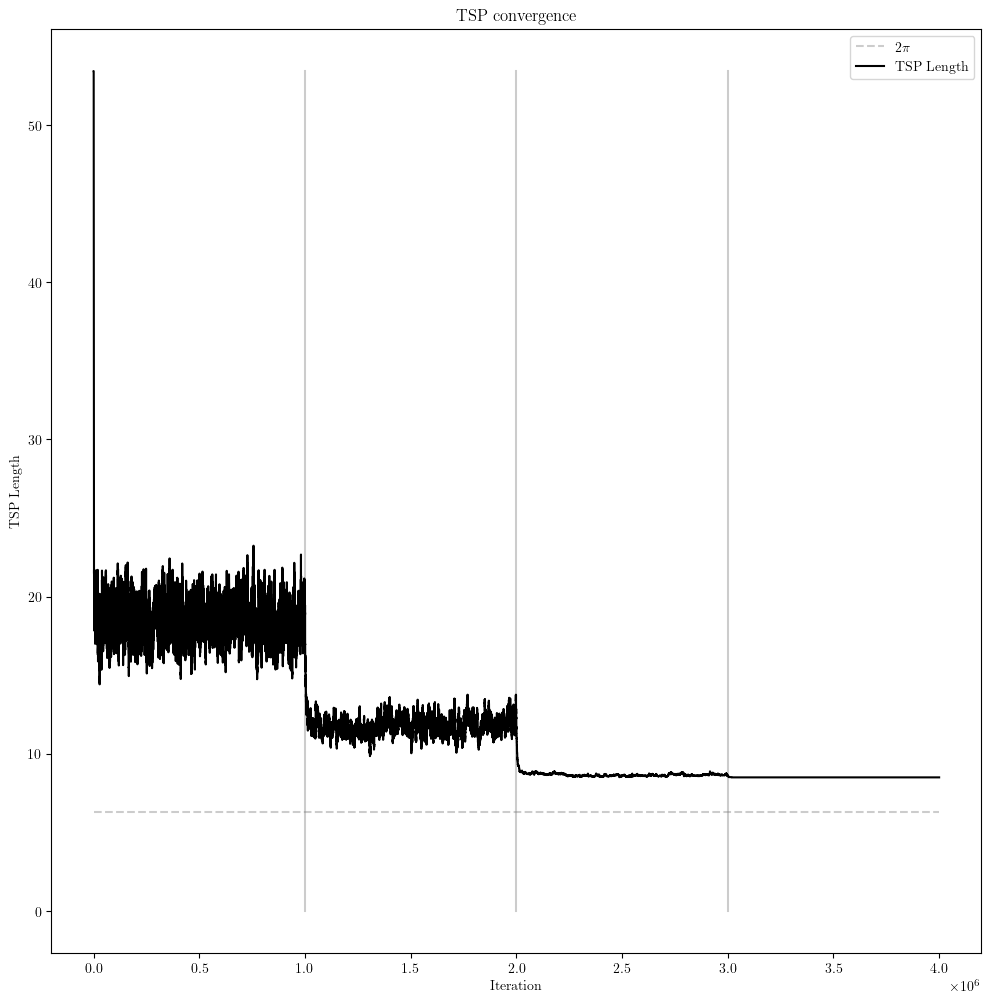

In [35]:
simulated_annealing_improved(nodes=nodes)

## Time-Dependent Simulated Annealing
stationary tsp -> time-dependent tsp:
change metric to include traffic jam area where the ts is slow after time step $M$

In [ ]:
# implement time-dependent algorithm
def simulated_annealing_time_dependent(
        nodes : np.ndarray, 
        temperatures = [0.1, 0.01, 0.001], 
        repetitions = 10000, 
        want_plot=True,
        f : float = 0.5, 
        M : int = 5, 
        traffic_jam_area : np.ndarray = np.array([[xmin:=0.25, xmax:=0.75], [ymin:=0.25, ymax:=0.75]])
        ) -> None:
    """
    simulated annealing algorithm for the time-dependent traveling salesman problem

    :param nodes: array of coordinates of the N nodes
    :type nodes: np.ndarray (N, d)

    :param temperatures: list of decreasing temperatures for the annealing 
    :type temperatures: list of float

    :param repetitions: number of repetitions per temperature
    :type repetitions: int

    :param want_plots: want a graphical output of the plots
    :type want_plots: boolean

    :param f: decrease in speed factor within the traffic jam area
    :type f: float

    :param M: starting time of the traffic jam (additional distance factor)
    :type M: int

    :param traffic_jam_area: area of the traffic jam defined by [[xmin, xmax], [ymin, ymax]]
    :type traffic_jam_area: np.ndarray (2, 2)
    
    :return: None
    """

    N = len(nodes)

    # calculate the distance matrix D_{i,j} once
    # D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    # nodes shape: (N, 2)
    differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
    D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)

    # randomly generate starting permutation
    starting_perm = np.random.permutation(N)
    # print(starting_perm, min(starting_perm), max(starting_perm))

    length_arr = []

    current_perm = starting_perm.copy()
    current_length = metric_time_dep_vectorized(
        node_coordinates=nodes,
        distance_matrix=D,
        permutation=current_perm,
        f=f,
        M=M,
        traffic_jam_area=traffic_jam_area
    )  # time dependent metric (only difference to previous function)

    temperature_step = 0  # for loading bar
    for temperature in temperatures:
        for repetition in range(repetitions):
            for i in range(N):
                # sample j from 0 to N-1 with j=!i
                choices = np.arange(N)
                j = np.random.choice(choices[choices != i])

                # generate new permutation
                i_tilde, j_tilde = min(i,j), max(i,j)
                trial_perm = current_perm.copy()
                trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
                trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]
                # calculate corresponding length
                trial_length = metric_time_dep_vectorized(
                node_coordinates=nodes,
                distance_matrix=D,
                permutation=trial_perm,
                f=f,
                M=M,
                traffic_jam_area=traffic_jam_area
                )   # time dependent metric (only difference to previous function)

                length_arr.append(trial_length)

                # accept reject step
                if trial_length < current_length:
                    current_perm = trial_perm.copy()
                    current_length = trial_length
                else:
                    x = np.random.rand()
                    if x < np.exp((current_length - trial_length) / temperature):
                        current_perm = trial_perm.copy()
                        current_length = trial_length 
                
            # loading bar
            fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
            bar_length = 40
            filled_length = int(bar_length * fraction)
            bar = '=' * filled_length + '-' * (bar_length - filled_length)
            print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
        temperature_step += 1
    
    if want_plot:
        # plot the tour
        plt.figure(figsize=(12,12))
        plt.title(f"TSP solution, length {current_length:4f}")

        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        # plot traffic jam area
        rectangle = plt.Rectangle(
            (traffic_jam_area[0,0], traffic_jam_area[1,0]),
            traffic_jam_area[0,1] - traffic_jam_area[0,0],
            traffic_jam_area[1,1] - traffic_jam_area[1,0],
            color='gray',
            alpha=0.3,
            label='Traffic Jam Area'
        )
        plt.gca().add_artist(rectangle)
        # label start point
        plt.text(
            nodes[current_perm[0], 0] + 0.02,
            nodes[current_perm[0], 1] + 0.02,
            'Start',
            fontsize=12,
            fontweight='bold',
            color='blue',
            ha='right',
            va='bottom'
        )
        
        # tour
        plt.scatter(nodes[:, 0], nodes[:,1], color='black')
        tour = np.append(current_perm, current_perm[0])  # close tour
        plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
        plt.savefig('simulated_annealing_final_tour.pdf')
        plt.show()

        print(current_perm)

        # plot the convergence
        plt.figure(figsize=(12,12))
        plt.title(f"TSP convergence")
        plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label=r'2$\pi$')
        for i in range(1, len(temperatures)):
            plt.plot([i * N * repetitions, i * N * repetitions], [0, max(length_arr)], alpha = 0.4, color='grey')
        plt.plot(length_arr, color='black', label='TSP Length')
        plt.legend()
        plt.savefig('tsp_sim_annealing_convergence.pdf')
        plt.show()


Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

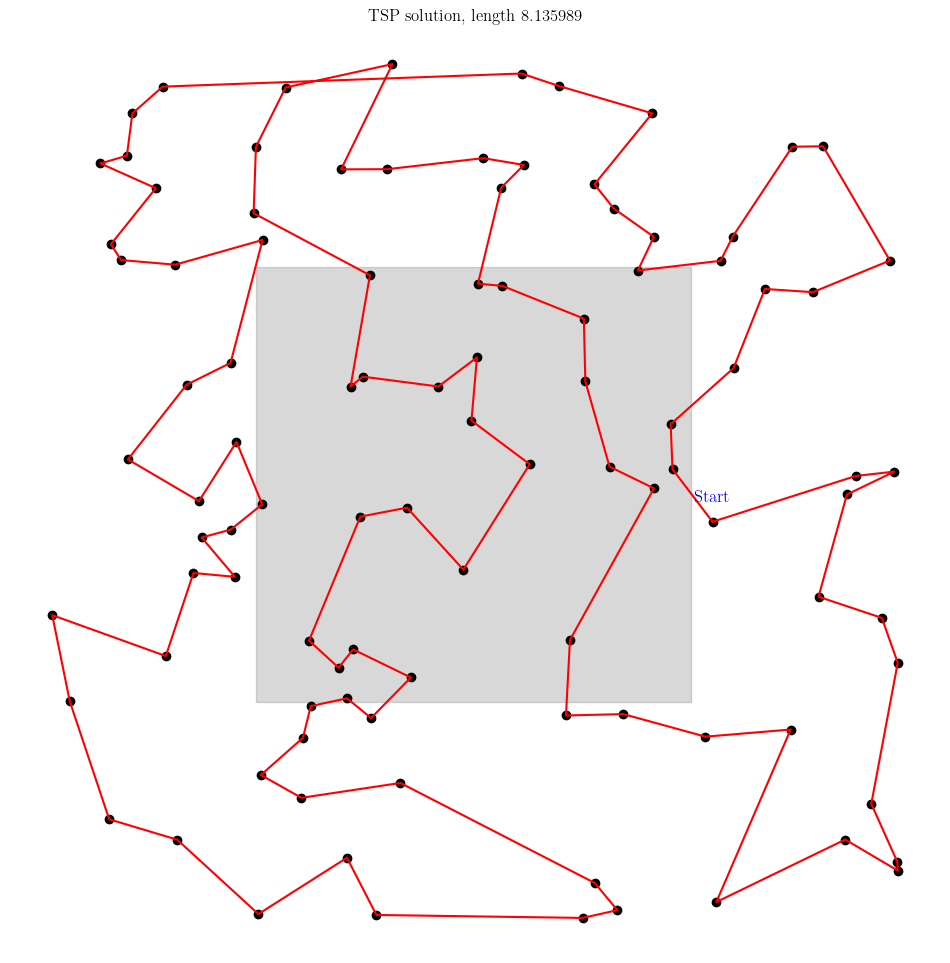

[35 91 19  3 73  8 37 45 82 97 10 67 98 34 44 23 13 87 29 15 36 53 75  1
 56 11 51 30 57 52 94  5 27 33 28 20 62 89 69 47 24 74 50 84 68  6  9 17
 80 77 59 81 85 95  7 49 25 83 93 88 21 54 48 12 79 60 16 18 72 78 14 63
  4 66 40 55 43 58 42 65 71 46 22 61 90 39 96 99 70 31 76 86 41 26 92 32
 64 38  0  2]


RuntimeError: latex was not able to process the following string:
b'2\\\\pi'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.4) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-06-01> patch level 1
L3 programming layer <2025-08-13>
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\t1cmr.fd))
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\inputenc.sty)
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/g

Error in callback <function _draw_all_if_interactive at 0x00000247818D5620> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'2\\\\pi'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.4) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-06-01> patch level 1
L3 programming layer <2025-08-13>
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\t1cmr.fd))
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\inputenc.sty)
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/g

RuntimeError: latex was not able to process the following string:
b'2\\\\pi'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (MiKTeX 25.4) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-06-01> patch level 1
L3 programming layer <2025-08-13>
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\t1cmr.fd))
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/base\inputenc.sty)
(C:\Users\steff\AppData\Local\Programs\MiKTeX\tex/latex/g

<Figure size 1200x1200 with 1 Axes>

In [27]:
# try time dependent TSP on random points in unit square
simulated_annealing_time_dependent(nodes=nodes)